In [153]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")

## Accident Risk Prediction

In [154]:
df = pd.read_csv("../data/traffic_featured.csv")

print(df.shape)

df.head()

(120000, 25)


,timestamp,hour,day_of_week,geohash_location,road_type,num_lanes,traffic_signals,large_vehicles_count,temperature,humidity,...,event_Concert,event_Conference,event_Festival,event_Sports_Event,peak_hour_flag,weekend_flag,rush_hour_indicator,signal_density,weather_impact_score,traffic_density_score
0,2023-01-01 00:00:00,0,6,38,4,3,0.817106,-1.415303,-0.912469,0.113391,...,False,False,False,False,0,1,0,0.272369,0.247931,0.040868
1,2023-01-01 00:05:00,0,6,28,0,5,-1.223831,0.706767,-0.927065,0.834313,...,False,False,True,False,0,1,0,-0.244766,0.290970,0.146096
2,2023-01-01 00:10:00,0,6,14,3,3,-1.223831,0.353089,-0.994952,-0.006479,...,False,False,False,False,0,1,0,-0.407944,0.233829,0.075041
3,2023-01-01 00:15:00,0,6,42,3,4,0.817106,0.706767,-1.580376,0.593531,...,False,False,False,False,0,1,0,0.204277,0.222750,0.072973
4,2023-01-01 00:20:00,0,6,7,0,4,0.817106,-0.707946,-1.056254,-0.559013,...,False,False,False,False,0,1,0,0.204277,0.194912,0.078544


In [155]:

vehicle_scaler = MinMaxScaler()

df["large_vehicles_count_normalized"] = vehicle_scaler.fit_transform(
    df[["large_vehicles_count"]]
)

In [156]:
df["traffic_density_index"] = (
    df["traffic_signals"] +
    df["large_vehicles_count"]
) / df["num_lanes"]

In [157]:
density_scaler = MinMaxScaler()

df["traffic_density_index"] = density_scaler.fit_transform(
    df[["traffic_density_index"]]
)

In [158]:
df["accident_risk_score"] = (
      0.4 * df["traffic_density_index"]
    + 0.3 * df["weather_impact_score"]
    + 0.3 * df["large_vehicles_count_normalized"]
)

In [159]:
def accident_risk_category(score):

    if score < 0.3:
        return "Low"

    elif score <= 0.6:
        return "Medium"

    else:
        return "High"


df["accident_risk_level"] = df["accident_risk_score"].apply(
    accident_risk_category
)

print(df["accident_risk_level"].value_counts())

accident_risk_level
Medium    102580
Low        16901
High         519
Name: count, dtype: int64


In [160]:
from sklearn.preprocessing import LabelEncoder

risk_encoder = LabelEncoder()

df["accident_target"] = risk_encoder.fit_transform(
    df["accident_risk_level"]
)

print("Classes:")

for i, cls in enumerate(risk_encoder.classes_):
    print(i, "->", cls)

Classes:
0 -> High
1 -> Low
2 -> Medium


In [161]:
# Features for Accident Risk Prediction
X_risk = df.drop(
    columns=[
        "accident_target",
        "accident_risk_level",
        "traffic_demand",
        "traffic_density_score",
        "timestamp"
    ]
)

# Target for Accident Risk Prediction
y_risk = df["accident_target"]

In [162]:
from sklearn.model_selection import train_test_split

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.20,
    random_state=42,
    stratify=y_risk
)

In [163]:
from lightgbm import LGBMClassifier

risk_classifier = LGBMClassifier(

    n_estimators=300,

    learning_rate=0.05,

    num_leaves=64,

    random_state=42
)

risk_classifier.fit(
    X_train_risk,
    y_train_risk
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005838 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1665
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 25
[LightGBM] [Info] Start training from score -5.443825
[LightGBM] [Info] Start training from score -1.960104
[LightGBM] [Info] Start training from score -0.156849
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

,num_leaves,64
,learning_rate,0.05
,n_estimators,300
,random_state,42
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [164]:
risk_pred = risk_classifier.predict(
    X_test_risk
)

### Accuracy

In [165]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test_risk,
    risk_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9988


### Weighted F1 Score

In [166]:
from sklearn.metrics import f1_score

f1 = f1_score(

    y_test_risk,

    risk_pred,

    average="weighted"
)

print(f"Weighted F1 Score : {f1:.4f}")

Weighted F1 Score : 0.9987


In [167]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_test_risk,

        risk_pred,

        target_names=risk_encoder.classes_

    )

)

              precision    recall  f1-score   support

        High       1.00      0.90      0.95       104
         Low       0.99      1.00      1.00      3380
      Medium       1.00      1.00      1.00     20516

    accuracy                           1.00     24000
   macro avg       1.00      0.97      0.98     24000
weighted avg       1.00      1.00      1.00     24000



### Confusion Matrix

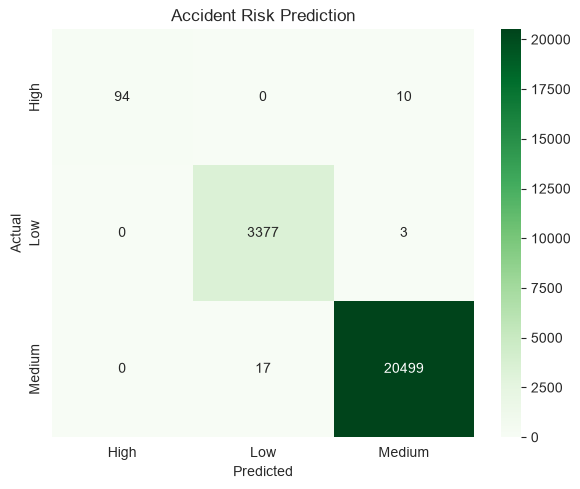

In [168]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_risk,
    risk_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens",

    xticklabels=risk_encoder.classes_,

    yticklabels=risk_encoder.classes_

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Accident Risk Prediction")

plt.tight_layout()

plt.savefig(
    "../visualizations/accident_risk_confusion_matrix.png",
    dpi=300
)

plt.show()

In [169]:
import joblib

joblib.dump(

    risk_classifier,

    "../models/accident_risk_classifier.pkl"

)

['../models/accident_risk_classifier.pkl']

## Route Recommendation Logic

### Load Best Regression Model

In [170]:
import sys
import importlib

sys.path.append("../src")

import ensemble_model
importlib.reload(ensemble_model)


<module 'ensemble_model' from 'c:\\Users\\THEERTHA\\Desktop\\ML_Internship\\traffic-prediction\\notebooks\\../src\\ensemble_model.py'>

In [171]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [172]:
from sklearn.model_selection import train_test_split

X_reg = df.drop(columns=[
        "traffic_demand",
        "traffic_density_score",
        "timestamp"
        
])

y_reg = df["traffic_demand"]

In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [174]:
X_train_reg = X_train.copy()
X_test_reg = X_test.copy()

X_train_reg = X_train_reg.drop(columns=[
    "large_vehicles_count_normalized",
    "traffic_density_index",
    "accident_risk_score",
    "accident_risk_level",
    "accident_target"
], errors="ignore")

X_test_reg = X_test_reg.drop(columns=[
    "large_vehicles_count_normalized",
    "traffic_density_index",
    "accident_risk_score",
    "accident_risk_level",
    "accident_target"
], errors="ignore")

In [176]:
ensemble_pred = ensemble_model.ensemble_predict(X_test_reg)

### Congestion Function

In [177]:
def congestion_level(prediction):

    if prediction < 1500:
        return "Low"

    elif prediction <= 3000:
        return "Medium"

    else:
        return "High"

In [178]:
import joblib

lgbm = joblib.load("../models/lightgbm.pkl")
xgb = joblib.load("../models/xgboost.pkl")

### Recommendation Function

In [179]:
def recommend_route(origin, destination, travel_datetime):

    travel_datetime = pd.to_datetime(travel_datetime)

    # Candidate zones

    candidates = df.copy()

    # remove origin and destination

    candidates = candidates[
        ~candidates["geohash_location"].isin(
            [origin, destination]
        )
    ]

    # nearest timestamp

    candidates["time_difference"] = (
        candidates["timestamp"] -
        travel_datetime
    ).abs()

    candidates = candidates.sort_values(
        "time_difference"
    )

    # keep nearest observation for every zone

    candidates = candidates.groupby(
        "geohash_location",
        as_index=False
    ).first()

    # Features
   
    X_predict = candidates[list(xgb.feature_names_in_)].copy()

    # Predict

    candidates["predicted_traffic"] = ensemble_model.ensemble_predict(
        X_predict
    )

    # Congestion

    candidates["congestion_level"] = (

        candidates["predicted_traffic"]

        .apply(congestion_level)

    )
    # Rank
    

    recommendations = (

        candidates

        .sort_values(
            "predicted_traffic"
        )

        [[

            "geohash_location",

            "predicted_traffic",

            "congestion_level"

        ]]

        .head(3)

    )

    recommendations = recommendations.rename(

        columns={

            "geohash_location":
            "recommended_zone",

            "predicted_traffic":
            "predicted_traffic_demand"

        }

    )
    geohash_encoder = joblib.load("../models/geohash_encoder.pkl")

    recommendations["recommended_zone"] = (
    geohash_encoder.inverse_transform(
        recommendations["recommended_zone"]
    )
)

    return recommendations

### Example for route recommendation

In [180]:
recommendations = recommend_route(

    origin="gc38",

    destination="gc42",

    travel_datetime="2023-01-15 08:30:00"

)

recommendations

,recommended_zone,predicted_traffic_demand,congestion_level
40,gc40,204.584801,Low
12,gc12,211.940896,Low
6,gc06,226.267113,Low
